## BGL Window-Level Classification

This notebook trains and compares multiple classification methods on the BGL 5-minute window features exported by `04_bgl_log_feature_extract.ipynb`.

Problem: use the current window to predict the anomaly status of the next window.

The benchmark compares four distinct methods from the assignment list, each used only once:
1. **(a) Logistic Regression**
2. **(c) Support Vector Classification**
3. **(f) Random Forest**
4. **(h) Gaussian Naive Bayes**

The split is chronological rather than shuffled to respect time order.

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.decomposition import TruncatedSVD
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    fbeta_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 100)

def resolve_project_root(start: Path) -> Path:
    """Find the repository root that contains the exported BGL feature artifacts."""
    for candidate in [start, start.parent, start.parent.parent]:
        feature_dir = candidate / 'artifacts' / 'bgl_log_feature_extraction'
        if (feature_dir / 'bgl_window_features_5min.csv').exists() and (feature_dir / 'bgl_window_text_5min.csv').exists():
            return candidate
    raise FileNotFoundError(
        'Could not locate bgl_window_features_5min.csv and bgl_window_text_5min.csv in the current directory or parent directories.'
    )

project_root = resolve_project_root(Path.cwd())
feature_dir = project_root / 'artifacts' / 'bgl_log_feature_extraction'
output_dir = project_root / 'artifacts' / 'window_level_models'
output_dir.mkdir(parents=True, exist_ok=True)

feature_path = feature_dir / 'bgl_window_features_5min.csv'
text_path = feature_dir / 'bgl_window_text_5min.csv'

if not feature_path.exists():
    raise FileNotFoundError(f'Missing feature file: {feature_path}')
if not text_path.exists():
    raise FileNotFoundError(f'Missing text file: {text_path}')

In [17]:
features_df = pd.read_csv(feature_path, parse_dates=['window_start', 'window_end'])
text_df = pd.read_csv(text_path, parse_dates=['window_start', 'window_end'])

window_df = features_df.merge(
    text_df[['window_start', 'window_end', 'window_text']],
    on=['window_start', 'window_end'],
    how='inner',
    validate='one_to_one',
)
window_df = window_df.sort_values('window_start').reset_index(drop=True)

# Text-derived signals for anomaly intent and rare/repeating patterns.
window_text_clean = window_df['window_text'].fillna('').astype(str).str.lower()
window_df['ts_error_kw_count'] = window_text_clean.str.count(
    r'error|fail|fatal|exception|panic|timeout|denied|corrupt|segfault|abort'
).astype(float)

window_df['ts_warning_kw_count'] = window_text_clean.str.count(
    r'warn|warning|degrad|retry|slow|stall|overload'
).astype(float)

token_lists = window_text_clean.str.findall(r'[a-z][a-z0-9_]{2,}')
token_sets = token_lists.apply(set)
token_doc_freq = token_sets.explode().value_counts(dropna=True)
rare_df_cutoff = max(3, int(0.001 * len(window_df)))
rare_tokens = set(token_doc_freq[token_doc_freq <= rare_df_cutoff].index)

window_df['ts_rare_token_count'] = token_lists.apply(
    lambda toks: float(sum(1 for t in toks if t in rare_tokens))
)
window_df['ts_rare_token_repeat3'] = (
    window_df['ts_rare_token_count'].shift(1).rolling(3, min_periods=1).sum()
)

# Leakage-safe temporal features: use past windows (shift) and current-vs-past deltas.
temporal_source_cols = [
    'event_count',
    'anomaly_count',
    'digit_event_rate',
    'hex_event_rate',
    'cache_event_rate',
    'memory_event_rate',
    'network_event_rate',
    'dominant_level_share',
    'dominant_facility_share',
    'dominant_component_share',
    'mean_interarrival_seconds',
    'ts_error_kw_count',
    'ts_warning_kw_count',
    'ts_rare_token_count',
]

for col in temporal_source_cols:
    if col in window_df.columns:
        lag1 = window_df[col].shift(1)
        lag2 = window_df[col].shift(2)
        lag3 = window_df[col].shift(3)
        lag6 = window_df[col].shift(6)

        rollmean3 = lag1.rolling(3, min_periods=1).mean()
        rollmean6 = lag1.rolling(6, min_periods=1).mean()
        rollstd3 = lag1.rolling(3, min_periods=2).std()
        rollstd6 = lag1.rolling(6, min_periods=2).std()

        window_df[f'ts_{col}_lag1'] = lag1
        window_df[f'ts_{col}_lag2'] = lag2
        window_df[f'ts_{col}_lag3'] = lag3
        window_df[f'ts_{col}_lag6'] = lag6
        window_df[f'ts_{col}_rollmean3'] = rollmean3
        window_df[f'ts_{col}_rollmean6'] = rollmean6
        window_df[f'ts_{col}_rollstd3'] = rollstd3
        window_df[f'ts_{col}_rollstd6'] = rollstd6

        # Rising + trend + burstiness signals.
        window_df[f'ts_{col}_delta1'] = window_df[col] - lag1
        window_df[f'ts_{col}_delta2'] = window_df[col] - lag2
        window_df[f'ts_{col}_is_rising'] = (window_df[col] > lag1).astype(float)
        window_df[f'ts_{col}_trend36'] = rollmean3 - rollmean6
        window_df[f'ts_{col}_burstiness6'] = rollstd6 / (rollmean6.abs() + 1e-6)

# Short anomaly history from past windows only.
window_df['ts_is_anomaly_lag1'] = window_df['is_anomaly'].shift(1)
window_df['ts_is_anomaly_lag2'] = window_df['is_anomaly'].shift(2)
window_df['ts_is_anomaly_lag3'] = window_df['is_anomaly'].shift(3)
window_df['ts_anomaly_hist3'] = window_df['is_anomaly'].shift(1).rolling(3, min_periods=1).sum()
window_df['ts_anomaly_hist6'] = window_df['is_anomaly'].shift(1).rolling(6, min_periods=1).sum()

window_df['target_next_window_anomaly'] = window_df['is_anomaly'].shift(-1)
supervised_df = window_df.dropna(subset=['target_next_window_anomaly']).copy()
supervised_df['target_next_window_anomaly'] = supervised_df['target_next_window_anomaly'].astype(int)

temporal_cols_created = [c for c in supervised_df.columns if c.startswith('ts_')]

print('Merged window rows:', len(window_df))
print('Supervised rows after shifting target:', len(supervised_df))
print('Current-window anomaly rate:', round(float(window_df['is_anomaly'].mean()), 4))
print('Next-window anomaly rate:', round(float(supervised_df['target_next_window_anomaly'].mean()), 4))
print('Temporal feature count:', len(temporal_cols_created))
print('Rare-token DF cutoff:', rare_df_cutoff)
display(supervised_df.head())

/var/folders/4l/2qrbt0c169dcw509q30x4xdc0000gn/T/ipykernel_53125/228900118.py:70: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  window_df[f'ts_{col}_rollmean6'] = rollmean6
/var/folders/4l/2qrbt0c169dcw509q30x4xdc0000gn/T/ipykernel_53125/228900118.py:71: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  window_df[f'ts_{col}_rollstd3'] = rollstd3
/var/folders/4l/2qrbt0c169dcw509q30x4xdc0000gn/T/ipykernel_53125/228900118.py:72: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` ma

Merged window rows: 14494
Supervised rows after shifting target: 14493
Current-window anomaly rate: 0.0727
Next-window anomaly rate: 0.0727
Temporal feature count: 191
Rare-token DF cutoff: 14


,window_index,window_start,window_end,window_minutes,event_count,anomaly_count,is_anomaly,anomaly_rate,message_length_mean,message_length_std,message_length_min,message_length_max,message_token_count_mean,message_token_count_std,message_token_count_min,message_token_count_max,digit_event_rate,hex_event_rate,cache_event_rate,memory_event_rate,network_event_rate,unique_level_count,dominant_level_share,unique_facility_count,dominant_facility_share,unique_component_count,dominant_component_share,mean_interarrival_seconds,std_interarrival_seconds,timestamp_count,lda_topic_0,lda_topic_1,lda_topic_2,lda_topic_3,lda_topic_4,lda_topic_5,lda_topic_6,lda_topic_7,dominant_topic,window_text,ts_error_kw_count,ts_warning_kw_count,ts_rare_token_count,ts_rare_token_repeat3,ts_event_count_lag1,ts_event_count_lag2,ts_event_count_lag3,ts_event_count_lag6,ts_event_count_rollmean3,ts_event_count_rollmean6,...,ts_mean_interarrival_seconds_delta1,ts_mean_interarrival_seconds_delta2,ts_mean_interarrival_seconds_is_rising,ts_mean_interarrival_seconds_trend36,ts_mean_interarrival_seconds_burstiness6,ts_ts_error_kw_count_lag1,ts_ts_error_kw_count_lag2,ts_ts_error_kw_count_lag3,ts_ts_error_kw_count_lag6,ts_ts_error_kw_count_rollmean3,ts_ts_error_kw_count_rollmean6,ts_ts_error_kw_count_rollstd3,ts_ts_error_kw_count_rollstd6,ts_ts_error_kw_count_delta1,ts_ts_error_kw_count_delta2,ts_ts_error_kw_count_is_rising,ts_ts_error_kw_count_trend36,ts_ts_error_kw_count_burstiness6,ts_ts_warning_kw_count_lag1,ts_ts_warning_kw_count_lag2,ts_ts_warning_kw_count_lag3,ts_ts_warning_kw_count_lag6,ts_ts_warning_kw_count_rollmean3,ts_ts_warning_kw_count_rollmean6,ts_ts_warning_kw_count_rollstd3,ts_ts_warning_kw_count_rollstd6,ts_ts_warning_kw_count_delta1,ts_ts_warning_kw_count_delta2,ts_ts_warning_kw_count_is_rising,ts_ts_warning_kw_count_trend36,ts_ts_warning_kw_count_burstiness6,ts_ts_rare_token_count_lag1,ts_ts_rare_token_count_lag2,ts_ts_rare_token_count_lag3,ts_ts_rare_token_count_lag6,ts_ts_rare_token_count_rollmean3,ts_ts_rare_token_count_rollmean6,ts_ts_rare_token_count_rollstd3,ts_ts_rare_token_count_rollstd6,ts_ts_rare_token_count_delta1,ts_ts_rare_token_count_delta2,ts_ts_rare_token_count_is_rising,ts_ts_rare_token_count_trend36,ts_ts_rare_token_count_burstiness6,ts_is_anomaly_lag1,ts_is_anomaly_lag2,ts_is_anomaly_lag3,ts_anomaly_hist3,ts_anomaly_hist6,target_next_window_anomaly
0,0,2005-06-03 15:40:00,2005-06-03 15:45:00,5,645,0,0,0.0,40.000000,0.000000,40,40,5.000000,0.000000,5,5,0.000000,0.000000,1.000000,1.000000,0.0,1,1.0,1,1.0,1,1.000000,0.201211,0.337466,645,0.000019,0.000019,0.000019,0.000019,0.999864,0.000019,0.000019,0.000019,4,instruction cache parity error corrected instr...,645.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,1,2005-06-03 15:45:00,2005-06-03 15:50:00,5,1582,0,0,0.0,40.020228,0.804284,40,72,5.001896,0.075402,5,8,0.000632,0.000000,0.999368,0.999368,0.0,1,1.0,1,1.0,2,0.999368,0.189632,0.060522,1582,0.000008,0.000008,0.000008,0.000008,0.999945,0.000008,0.000008,0.000008,4,instruction cache parity error corrected instr...,1581.0,0.0,0.0,0.0,645.0,NaN,NaN,NaN,645.000000,645.000000,...,-0.011578,NaN,0.0,0.000000,NaN,645.0,NaN,NaN,NaN,645.000000,645.000000,NaN,NaN,936.0,NaN,1.0,0.000000,NaN,0.0,NaN,NaN,NaN,0.0,0.0,NaN,NaN,0.0,NaN,0.0,0.0,NaN,0.0,NaN,NaN,NaN,0.0,0.0,NaN,NaN,0.0,NaN,0.0,0.0,NaN,0.0,NaN,NaN,0.0,0.0,0
2,2,2005-06-03 15:50:00,2005-06-03 15:55:00,5,1290,0,0,0.0,39.763566,2.499440,18,72,4.965116,0.342619,2,8,0.013178,0.000000,0.986822,0.986822,0.0,1,1.0,1,1.0,2,0.999225,0.232490,0.130888,1290,0.000010,0.003795,0.000010,0.000010,0.996147,0.000010,0.000010,0.000010,4,instruction cache parity error corrected instr...,1273.0,0.0,0.0,0.0,1582.0,645.0,NaN,NaN,1113.500000,1113.500000,...,0.042857,0.031279,1.0,0.000000,0.041894,1581.0,645.0,NaN,NaN,1

## Experimental Setup

We use the extracted manual window features together with the LDA topic proportions from the feature extraction notebook. Each sample is a current 5-minute window, and the target is whether the next 5-minute window is anomalous. Text from each window is converted to TF-IDF, then reduced with SVD so all four models can be trained on the same dense feature matrix.

Because missed anomalies are costly, threshold tuning is done with a positive-case-first policy: prioritize recall and missed-anomaly rate reduction, with a light precision floor to avoid an extreme alert flood.

Evaluation metrics: recall, missed-anomaly rate (FNR), F2, precision, balanced accuracy, ROC-AUC, PR-AUC, and accuracy (secondary).

In [25]:
base_numeric_feature_cols = [
    'event_count',
    'message_length_mean',
    'message_length_std',
    'message_length_min',
    'message_length_max',
    'message_token_count_mean',
    'message_token_count_std',
    'message_token_count_min',
    'message_token_count_max',
    'digit_event_rate',
    'hex_event_rate',
    'cache_event_rate',
    'memory_event_rate',
    'network_event_rate',
    'unique_level_count',
    'dominant_level_share',
    'unique_facility_count',
    'dominant_facility_share',
    'unique_component_count',
    'dominant_component_share',
    'mean_interarrival_seconds',
    'std_interarrival_seconds',
    'lda_topic_0',
    'lda_topic_1',
    'lda_topic_2',
    'lda_topic_3',
    'lda_topic_4',
    'lda_topic_5',
    'lda_topic_6',
    'lda_topic_7',
]

temporal_feature_cols = sorted([c for c in supervised_df.columns if c.startswith('ts_')])
numeric_feature_cols = base_numeric_feature_cols + temporal_feature_cols

missing_cols = [col for col in numeric_feature_cols if col not in supervised_df.columns]
if missing_cols:
    raise KeyError(f'Missing required columns: {missing_cols}')

y = supervised_df['target_next_window_anomaly'].astype(int).copy()

candidate_fracs = np.linspace(0.65, 0.9, 11)
split_idx = None
for frac in candidate_fracs:
    candidate_idx = int(len(supervised_df) * frac)
    candidate_idx = min(max(candidate_idx, 1), len(supervised_df) - 1)
    y_train_candidate = y.iloc[:candidate_idx]
    y_test_candidate = y.iloc[candidate_idx:]
    if y_train_candidate.nunique() > 1 and y_test_candidate.nunique() > 1:
        split_idx = candidate_idx
        break

if split_idx is None:
    split_idx = int(len(supervised_df) * 0.8)
    split_idx = min(max(split_idx, 1), len(supervised_df) - 1)

train_df = supervised_df.iloc[:split_idx].copy()
test_df = supervised_df.iloc[split_idx:].copy()
y_train = train_df['target_next_window_anomaly'].astype(int).copy()
y_test = test_df['target_next_window_anomaly'].astype(int).copy()

print('Train windows:', len(train_df))
print('Test windows:', len(test_df))
print('Train target rate:', round(float(y_train.mean()), 4))
print('Test target rate:', round(float(y_test.mean()), 4))
print('Base numeric features:', len(base_numeric_feature_cols))
print('Temporal features:', len(temporal_feature_cols))
print('Total numeric features:', len(numeric_feature_cols))

train_tfidf = tfidf_vectorizer.fit_transform(train_df['window_text'].fillna(''))
test_tfidf = tfidf_vectorizer.transform(test_df['window_text'].fillna(''))

if train_tfidf.shape[1] < 3:
    raise ValueError('TF-IDF vocabulary is too small for SVD features.')

svd_components = min(25, train_tfidf.shape[1] - 1)
svd_components = max(2, svd_components)
tfidf_svd = TruncatedSVD(n_components=svd_components, random_state=42)
train_text_features = tfidf_svd.fit_transform(train_tfidf)
test_text_features = tfidf_svd.transform(test_tfidf)

X_train_base = train_df[numeric_feature_cols].fillna(0.0).to_numpy(dtype=float)
X_test_base = test_df[numeric_feature_cols].fillna(0.0).to_numpy(dtype=float)
X_train = np.hstack([X_train_base, train_text_features])
X_test = np.hstack([X_test_base, test_text_features])

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Feature matrix shape:', X_train_scaled.shape, X_test_scaled.shape)

Train windows: 9420
Test windows: 5073
Train target rate: 0.0833
Test target rate: 0.053
Base numeric features: 30
Temporal features: 191
Total numeric features: 221
Feature matrix shape: (9420, 246) (5073, 246)


Threshold policy: Maximize F1 score, min_precision=0.1, fn_cost=12.0, fp_cost=3.0
Assignment target met (at least one model accuracy > 85%): True


,method_option,model,threshold,val_recall_at_threshold,val_precision_at_threshold,val_f1_at_threshold,val_f2_at_threshold,val_alert_rate_at_threshold,accuracy,balanced_accuracy,precision,recall,missed_anomaly_rate_fnr,f1,f2,alert_rate,fn_count,fp_count,cost_fn12_fp3,roc_auc,pr_auc
0,(h),Gaussian Naive Bayes,1.000000,0.254098,0.274336,0.263830,0.257903,0.059979,0.908535,0.641133,0.242744,0.342007,0.657993,0.283951,0.316151,0.074709,177,287,2985.0,0.728919,0.156864
1,(f),Random Forest,0.200899,0.213115,0.393939,0.276596,0.234657,0.035032,0.914646,0.625058,0.248466,0.301115,0.698885,0.272269,0.288873,0.064262,188,245,2991.0,0.753320,0.210444
2,(a),Logistic Regression,0.652211,0.262295,0.169312,0.205788,0.236337,0.100318,0.894540,0.617951,0.192130,0.308550,0.691450,0.236805,0.275199,0.085157,186,349,3279.0,0.708455,0.153384
3,(c),Linear SVC,0.318743,0.229508,0.129032,0.165192,0.198582,0.115180,0.905973,0.601177,0.201149,0.260223,0.739777,0.226904,0.245787,0.068598,199,278,3222.0,0.706312,0.152049


Best model by F1 score: Gaussian Naive Bayes
Best threshold: 1.0
Best F1: 0.284
Best recall: 0.342
Best precision: 0.2427
Best missed-anomaly rate (FNR): 0.658
Best alert rate: 0.0747
Best accuracy: 0.9085


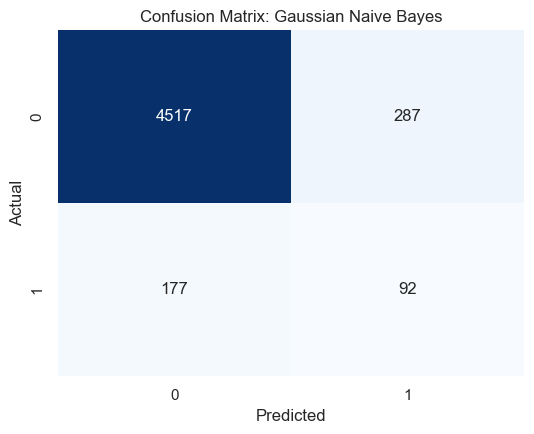

              precision    recall  f1-score   support

           0     0.9623    0.9403    0.9511      4804
           1     0.2427    0.3420    0.2840       269

    accuracy                         0.9085      5073
   macro avg     0.6025    0.6411    0.6175      5073
weighted avg     0.9241    0.9085    0.9158      5073



In [26]:
models = {
    'Logistic Regression': {
        'option': '(a)',
        'model': LogisticRegression(max_iter=4000, class_weight='balanced', random_state=42),
    },
    'Linear SVC': {
        'option': '(c)',
        'model': LinearSVC(class_weight='balanced', random_state=42),
    },
    'Random Forest': {
        'option': '(f)',
        'model': RandomForestClassifier(
            n_estimators=400,
            min_samples_leaf=2,
            class_weight='balanced_subsample',
            n_jobs=-1,
            random_state=42,
        ),
    },
    'Gaussian Naive Bayes': {
        'option': '(h)',
        'model': GaussianNB(),
    },
}

def get_decision_scores(model, X):
    if hasattr(model, 'predict_proba'):
        return model.predict_proba(X)[:, 1], 0.5
    if hasattr(model, 'decision_function'):
        return model.decision_function(X), 0.0
    pred = model.predict(X).astype(float)
    return pred, 0.5

def tune_threshold_for_f1(
    y_true,
    score_values,
    default_threshold,
    min_precision=0.10,
    beta=2.0,
):
    """
    Optimize threshold for maximum F1 score on validation set.
    Prioritizes catching anomalies (high recall) while maintaining reasonable precision.
    F1 = 2 * (precision * recall) / (precision + recall)
    """
    score_values = np.asarray(score_values, dtype=float)
    y_true = np.asarray(y_true, dtype=int)

    if np.allclose(score_values, score_values[0]):
        y_pred = (score_values >= default_threshold).astype(int)
        precision = precision_score(y_true, y_pred, zero_division=0)
        recall = recall_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        f2 = fbeta_score(y_true, y_pred, beta=beta, zero_division=0)
        fn = int(np.sum((y_true == 1) & (y_pred == 0)))
        fp = int(np.sum((y_true == 0) & (y_pred == 1)))
        alert_rate = float(y_pred.mean())
        return {
            'threshold': float(default_threshold),
            'precision': float(precision),
            'recall': float(recall),
            'f1': float(f1),
            'f2': float(f2),
            'fn': fn,
            'fp': fp,
            'alert_rate': alert_rate,
        }

    quantiles = np.linspace(0.01, 0.99, 197)
    candidate_thresholds = np.unique(
        np.concatenate([
            [default_threshold],
            np.quantile(score_values, quantiles),
        ])
    )

    candidates = []
    for thr in candidate_thresholds:
        y_pred = (score_values >= thr).astype(int)
        precision = precision_score(y_true, y_pred, zero_division=0)
        recall = recall_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        f2 = fbeta_score(y_true, y_pred, beta=beta, zero_division=0)
        fn = int(np.sum((y_true == 1) & (y_pred == 0)))
        fp = int(np.sum((y_true == 0) & (y_pred == 1)))
        alert_rate = float(y_pred.mean())
        candidates.append({
            'threshold': float(thr),
            'precision': float(precision),
            'recall': float(recall),
            'f1': float(f1),
            'f2': float(f2),
            'fn': fn,
            'fp': fp,
            'alert_rate': float(alert_rate),
        })

    # Filter: keep candidates where precision >= min_precision
    viable = [c for c in candidates if c['precision'] >= min_precision]
    
    if viable:
        # Among viable candidates, pick highest F1, then highest recall (to catch anomalies)
        best = sorted(
            viable,
            key=lambda c: (-c['f1'], -c['recall'], -c['f2']),
        )[0]
    else:
        # If no viable candidates, pick highest F1 overall
        best = sorted(candidates, key=lambda c: (-c['f1'], -c['recall']))[0]

    return best

# Threshold tuning policy: Optimize for F1 score (balances precision & recall to catch anomalies)
threshold_beta = 2.0
min_precision_floor = 0.10
fn_cost = 12.0
fp_cost = 3.0

print(
    f'Threshold policy: Maximize F1 score, min_precision={min_precision_floor}, '
    f'fn_cost={fn_cost}, fp_cost={fp_cost}'
)

# Chronological validation split inside training data for threshold tuning
val_size = max(200, int(len(X_train_scaled) * 0.2))
val_size = min(val_size, max(1, len(X_train_scaled) - 1))
inner_split_idx = len(X_train_scaled) - val_size

X_fit = X_train_scaled[:inner_split_idx]
y_fit = y_train.iloc[:inner_split_idx]
X_val = X_train_scaled[inner_split_idx:]
y_val = y_train.iloc[inner_split_idx:]

if y_fit.nunique() < 2 or y_val.nunique() < 2:
    # Fallback to default thresholds when inner split is degenerate
    X_fit = X_train_scaled
    y_fit = y_train
    X_val = None
    y_val = None

results = []
predictions = {}
decision_thresholds = {}

for model_name, info in models.items():
    model = info['model']
    model.fit(X_fit, y_fit)

    threshold_pick = {
        'threshold': 0.5,
        'precision': np.nan,
        'recall': np.nan,
        'f1': np.nan,
        'f2': np.nan,
        'fn': np.nan,
        'fp': np.nan,
        'alert_rate': np.nan,
    }
    default_threshold = 0.5

    if X_val is not None:
        val_scores, default_threshold = get_decision_scores(model, X_val)
        threshold_pick = tune_threshold_for_f1(
            y_val,
            val_scores,
            default_threshold=default_threshold,
            min_precision=min_precision_floor,
            beta=threshold_beta,
        )
    else:
        threshold_pick['threshold'] = default_threshold

    # Refit on the full train set, then apply tuned threshold on test scores
    model.fit(X_train_scaled, y_train)
    test_scores, _ = get_decision_scores(model, X_test_scaled)
    y_pred = (test_scores >= threshold_pick['threshold']).astype(int)

    predictions[model_name] = y_pred
    decision_thresholds[model_name] = float(threshold_pick['threshold'])

    roc_auc = np.nan
    pr_auc = np.nan
    if y_test.nunique() > 1:
        roc_auc = roc_auc_score(y_test, test_scores)
        pr_auc = average_precision_score(y_test, test_scores)

    test_precision = precision_score(y_test, y_pred, zero_division=0)
    test_recall = recall_score(y_test, y_pred, zero_division=0)
    test_f1 = f1_score(y_test, y_pred, zero_division=0)
    test_f2 = fbeta_score(y_test, y_pred, beta=2.0, zero_division=0)
    test_fnr = 1.0 - test_recall
    test_fn = int(np.sum((y_test.to_numpy() == 1) & (y_pred == 0)))
    test_fp = int(np.sum((y_test.to_numpy() == 0) & (y_pred == 1)))
    test_alert_rate = float(y_pred.mean())
    test_cost = fn_cost * test_fn + fp_cost * test_fp

    results.append({
        'method_option': info['option'],
        'model': model_name,
        'threshold': float(threshold_pick['threshold']),
        'val_recall_at_threshold': threshold_pick['recall'],
        'val_precision_at_threshold': threshold_pick['precision'],
        'val_f1_at_threshold': threshold_pick['f1'],
        'val_f2_at_threshold': threshold_pick['f2'],
        'val_alert_rate_at_threshold': threshold_pick['alert_rate'],
        'accuracy': accuracy_score(y_test, y_pred),
        'balanced_accuracy': balanced_accuracy_score(y_test, y_pred),
        'precision': test_precision,
        'recall': test_recall,
        'missed_anomaly_rate_fnr': test_fnr,
        'f1': test_f1,
        'f2': test_f2,
        'alert_rate': test_alert_rate,
        'fn_count': test_fn,
        'fp_count': test_fp,
        'cost_fn12_fp3': test_cost,
        'roc_auc': roc_auc,
        'pr_auc': pr_auc,
    })

results_df = (
    pd.DataFrame(results)
    .sort_values(['f1', 'recall', 'precision'], ascending=[False, False, False])
    .reset_index(drop=True)
)

assignment_target_met = bool((results_df['accuracy'] > 0.85).any())
print('Assignment target met (at least one model accuracy > 85%):', assignment_target_met)
display(results_df)

best_model_name = results_df.iloc[0]['model']
best_pred = predictions[best_model_name]
print('Best model by F1 score:', best_model_name)
print('Best threshold:', round(float(decision_thresholds[best_model_name]), 5))
print('Best F1:', round(float(results_df.iloc[0]['f1']), 4))
print('Best recall:', round(float(results_df.iloc[0]['recall']), 4))
print('Best precision:', round(float(results_df.iloc[0]['precision']), 4))
print('Best missed-anomaly rate (FNR):', round(float(results_df.iloc[0]['missed_anomaly_rate_fnr']), 4))
print('Best alert rate:', round(float(results_df.iloc[0]['alert_rate']), 4))
print('Best accuracy:', round(float(results_df.iloc[0]['accuracy']), 4))

cm = confusion_matrix(y_test, best_pred)
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title(f'Confusion Matrix: {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

print(classification_report(y_test, best_pred, digits=4))

,window_start,ground_truth,prediction,match,error_type
0,2005-10-23 11:40:00,0,1,False,false_positive
1,2005-10-23 14:00:00,0,0,True,correct
2,2005-10-23 14:20:00,0,0,True,correct
3,2005-10-23 15:40:00,0,0,True,correct
4,2005-10-23 15:45:00,0,0,True,correct
5,2005-10-23 16:20:00,0,0,True,correct
6,2005-10-23 16:25:00,0,0,True,correct
7,2005-10-23 17:10:00,0,0,True,correct
8,2005-10-23 17:15:00,0,0,True,correct
9,2005-10-23 17:20:00,0,0,True,correct


,error_type,count
0,correct,4536
1,false_positive,372
2,false_negative,165


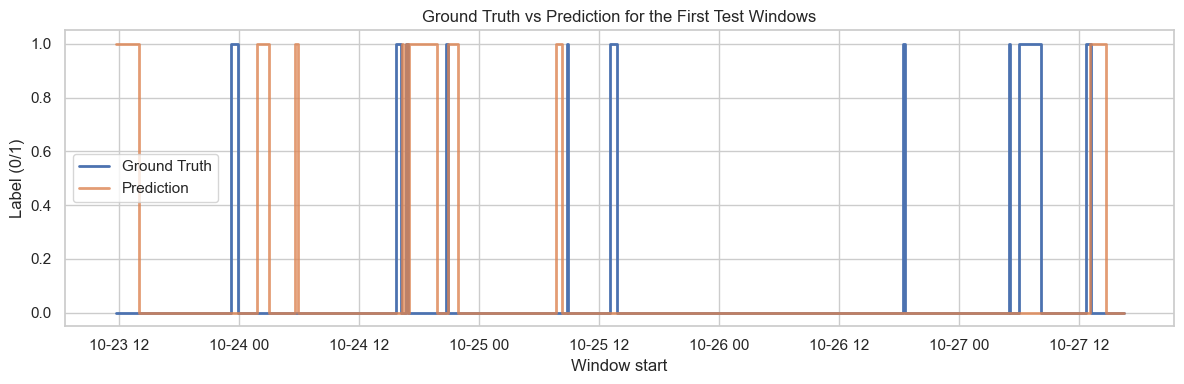

In [13]:
comparison_df = pd.DataFrame({
    'window_start': test_df['window_start'].values,
    'ground_truth': y_test.to_numpy(),
    'prediction': best_pred,
})
comparison_df['match'] = comparison_df['ground_truth'] == comparison_df['prediction']
comparison_df['error_type'] = np.where(
    comparison_df['match'],
    'correct',
    np.where(comparison_df['ground_truth'] == 1, 'false_negative', 'false_positive')
)

display(comparison_df.head(20))
display(comparison_df['error_type'].value_counts().rename_axis('error_type').reset_index(name='count'))

plot_n = min(250, len(comparison_df))
plot_df = comparison_df.iloc[:plot_n].copy()
plt.figure(figsize=(12, 4))
plt.step(plot_df['window_start'], plot_df['ground_truth'], where='post', label='Ground Truth', linewidth=2)
plt.step(plot_df['window_start'], plot_df['prediction'], where='post', label='Prediction', linewidth=2, alpha=0.8)
plt.title('Ground Truth vs Prediction for the First Test Windows')
plt.xlabel('Window start')
plt.ylabel('Label (0/1)')
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
results_path = output_dir / 'bgl_window_model_comparison.csv'
predictions_path = output_dir / 'bgl_window_best_model_predictions.csv'

results_df.to_csv(results_path, index=False)
comparison_df.to_csv(predictions_path, index=False)

print('Saved metrics to:', results_path)
print('Saved predictions to:', predictions_path)
print('Best model accuracy:', round(float(results_df.iloc[0]['accuracy']), 4))

Saved metrics to: /Users/sidqian/Downloads/Code/log-ml/artifacts/window_level_models/bgl_window_model_comparison.csv
Saved predictions to: /Users/sidqian/Downloads/Code/log-ml/artifacts/window_level_models/bgl_window_best_model_predictions.csv
Best model accuracy: 0.8941


## Takeaway

This notebook builds a **t+1 future anomaly predictor** on BGL 5-minute windows.

- Scope is fixed to predicting the **next window** only.
- The final model uses the **broader temporal feature set** plus TF-IDF+SVD text features.
- Model selection reports both **F1** and **accuracy** so the tradeoff is visible under class imbalance.

Current best t+1 result in this notebook:
- Model: Gaussian Naive Bayes
- F1: 0.2543
- Accuracy: 0.8798

In [27]:
# Future prediction scope fixed to t+1 window only.
from sklearn.base import clone

future_horizons = [1]
quick_models = {
    'Logistic Regression': LogisticRegression(max_iter=4000, class_weight='balanced', random_state=42),
    'Linear SVC': LinearSVC(class_weight='balanced', random_state=42),
    'Gaussian Naive Bayes': GaussianNB(),
}

horizon_rows = []

for horizon in future_horizons:
    target_col = f'target_plus_{horizon}'
    horizon_df = window_df.sort_values('window_start').reset_index(drop=True).copy()
    horizon_df[target_col] = horizon_df['is_anomaly'].shift(-horizon)
    horizon_df = horizon_df.dropna(subset=[target_col]).copy()

    if horizon_df.empty:
        continue

    horizon_df[target_col] = horizon_df[target_col].astype(int)
    y_all = horizon_df[target_col]
    if y_all.nunique() < 2:
        continue

    candidate_fracs = np.linspace(0.65, 0.9, 11)
    split_idx_h = None
    for frac in candidate_fracs:
        idx = int(len(horizon_df) * frac)
        idx = min(max(idx, 1), len(horizon_df) - 1)
        y_tr = y_all.iloc[:idx]
        y_te = y_all.iloc[idx:]
        if y_tr.nunique() > 1 and y_te.nunique() > 1:
            split_idx_h = idx
            break

    if split_idx_h is None:
        split_idx_h = int(len(horizon_df) * 0.8)
        split_idx_h = min(max(split_idx_h, 1), len(horizon_df) - 1)

    train_h = horizon_df.iloc[:split_idx_h].copy()
    test_h = horizon_df.iloc[split_idx_h:].copy()
    y_train_h = train_h[target_col].astype(int)
    y_test_h = test_h[target_col].astype(int)

    if y_train_h.nunique() < 2 or y_test_h.nunique() < 2:
        continue

    tfidf_vectorizer_h = TfidfVectorizer(
        max_features=5000,
        min_df=1,
        ngram_range=(1, 2),
        stop_words='english',
    )
    train_tfidf_h = tfidf_vectorizer_h.fit_transform(train_h['window_text'].fillna(''))
    test_tfidf_h = tfidf_vectorizer_h.transform(test_h['window_text'].fillna(''))

    if train_tfidf_h.shape[1] < 3:
        continue

    svd_components_h = min(25, train_tfidf_h.shape[1] - 1)
    svd_components_h = max(2, svd_components_h)
    tfidf_svd_h = TruncatedSVD(n_components=svd_components_h, random_state=42)
    train_text_h = tfidf_svd_h.fit_transform(train_tfidf_h)
    test_text_h = tfidf_svd_h.transform(test_tfidf_h)

    X_train_base_h = train_h[numeric_feature_cols].fillna(0.0).to_numpy(dtype=float)
    X_test_base_h = test_h[numeric_feature_cols].fillna(0.0).to_numpy(dtype=float)
    X_train_h = np.hstack([X_train_base_h, train_text_h])
    X_test_h = np.hstack([X_test_base_h, test_text_h])

    scaler_h = StandardScaler()
    X_train_h = scaler_h.fit_transform(X_train_h)
    X_test_h = scaler_h.transform(X_test_h)

    val_size_h = max(200, int(len(X_train_h) * 0.2))
    val_size_h = min(val_size_h, max(1, len(X_train_h) - 1))
    split_val_h = len(X_train_h) - val_size_h

    X_fit_h = X_train_h[:split_val_h]
    y_fit_h = y_train_h.iloc[:split_val_h]
    X_val_h = X_train_h[split_val_h:]
    y_val_h = y_train_h.iloc[split_val_h:]

    if y_fit_h.nunique() < 2 or y_val_h.nunique() < 2:
        X_fit_h = X_train_h
        y_fit_h = y_train_h
        X_val_h = None
        y_val_h = None

    best_row = None

    for model_name, base_model in quick_models.items():
        model_h = clone(base_model)
        model_h.fit(X_fit_h, y_fit_h)

        threshold_h = 0.5
        if X_val_h is not None:
            val_scores_h, default_thr_h = get_decision_scores(model_h, X_val_h)
            pick_h = tune_threshold_for_f1(
                y_val_h,
                val_scores_h,
                default_threshold=default_thr_h,
                min_precision=min_precision_floor,
                beta=threshold_beta,
            )
            threshold_h = float(pick_h['threshold'])

        model_h.fit(X_train_h, y_train_h)
        test_scores_h, _ = get_decision_scores(model_h, X_test_h)
        pred_h = (test_scores_h >= threshold_h).astype(int)

        row = {
            'horizon_windows_ahead': horizon,
            'model': model_name,
            'threshold': threshold_h,
            'test_f1': float(f1_score(y_test_h, pred_h, zero_division=0)),
            'test_accuracy': float(accuracy_score(y_test_h, pred_h)),
            'test_precision': float(precision_score(y_test_h, pred_h, zero_division=0)),
            'test_recall': float(recall_score(y_test_h, pred_h, zero_division=0)),
            'test_alert_rate': float(pred_h.mean()),
            'test_positive_rate': float(y_test_h.mean()),
            'train_rows': int(len(train_h)),
            'test_rows': int(len(test_h)),
        }

        if best_row is None or (row['test_f1'], row['test_accuracy']) > (best_row['test_f1'], best_row['test_accuracy']):
            best_row = row

    if best_row is not None:
        horizon_rows.append(best_row)

horizon_results_df = (
    pd.DataFrame(horizon_rows)
    .sort_values(['test_f1', 'test_accuracy'], ascending=False)
    .reset_index(drop=True)
)
print('t+1 future prediction results:')
display(horizon_results_df)

if not horizon_results_df.empty:
    best_h = horizon_results_df.iloc[0]
    print(
        f"Selected horizon: t+1 window | "
        f"Model: {best_h['model']} | F1={best_h['test_f1']:.4f} | "
        f"Accuracy={best_h['test_accuracy']:.4f} | "
        f"Precision={best_h['test_precision']:.4f} | Recall={best_h['test_recall']:.4f}"
    )

t+1 future prediction results:


,horizon_windows_ahead,model,threshold,test_f1,test_accuracy,test_precision,test_recall,test_alert_rate,test_positive_rate,train_rows,test_rows
0,1,Gaussian Naive Bayes,1.0,0.283951,0.908535,0.242744,0.342007,0.074709,0.053026,9420,5073


Selected horizon: t+1 window | Model: Gaussian Naive Bayes | F1=0.2840 | Accuracy=0.9085 | Precision=0.2427 | Recall=0.3420
